In [17]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque
from tqdm import trange

In [18]:
class MaskedLinear(nn.Linear):
    def __init__(self, in_features, out_features):
        super().__init__(in_features, out_features)
        self.register_buffer("weight_mask", torch.ones_like(self.weight))

    def forward(self, input):
        return F.linear(input, self.weight * self.weight_mask, self.bias)

class SquashedNormal:
    def __init__(self, mu, std):
        self.base_dist = torch.distributions.Normal(mu, std)

    def rsample(self):
        sample = self.base_dist.rsample()
        return torch.tanh(sample)

    def log_prob(self, value):
        raw_action = torch.atanh(value.clamp(-0.999, 0.999))
        log_prob = self.base_dist.log_prob(raw_action)
        log_prob -= torch.log(1 - value.pow(2) + 1e-6)
        return log_prob.sum(dim=-1)

class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.fc1 = MaskedLinear(state_dim, hidden_dim)
        self.fc2 = MaskedLinear(hidden_dim, hidden_dim)
        self.mu = MaskedLinear(hidden_dim, action_dim)
        self.log_std = MaskedLinear(hidden_dim, action_dim)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        mu = self.mu(x)
        log_std = self.log_std(x).clamp(-20, 2)
        std = torch.exp(log_std)
        dist = SquashedNormal(mu, std)
        action = dist.rsample()
        log_prob = dist.log_prob(action)
        return action, log_prob

class DoubleCritic(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.q1_fc1 = MaskedLinear(state_dim + action_dim, hidden_dim)
        self.q1_fc2 = MaskedLinear(hidden_dim, hidden_dim)
        self.q1_out = MaskedLinear(hidden_dim, 1)

        self.q2_fc1 = MaskedLinear(state_dim + action_dim, hidden_dim)
        self.q2_fc2 = MaskedLinear(hidden_dim, hidden_dim)
        self.q2_out = MaskedLinear(hidden_dim, 1)

    def forward(self, state, action):
        x = torch.cat([state, action], dim=-1)

        q1 = F.relu(self.q1_fc1(x))
        q1 = F.relu(self.q1_fc2(q1))
        q1 = self.q1_out(q1)

        q2 = F.relu(self.q2_fc1(x))
        q2 = F.relu(self.q2_fc2(q2))
        q2 = self.q2_out(q2)

        return q1.squeeze(-1), q2.squeeze(-1)

class ReplayBuffer:
    def __init__(self, max_size=10000):
        self.buffer = deque(maxlen=max_size)

    def add(self, transition):
        self.buffer.append(transition)

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        batch = list(zip(*batch))
        return tuple(torch.tensor(np.array(x), dtype=torch.float32) for x in batch)

    def __len__(self):
        return len(self.buffer)

class DAPDController:
    def __init__(self, model, sparsity=0.95):
        self.model = model
        self.sparsity = sparsity

    def compute_saliency(self, loss_fn, data_batch):
        self.model.zero_grad()
        loss = loss_fn(data_batch)
        loss.backward()
        grads_abs = []
        for module in self.model.modules():
            if isinstance(module, MaskedLinear):
                grads_abs.append(torch.abs(module.weight * module.weight.grad))
        return grads_abs

    def update(self, data_batch, loss_fn):
        saliencies = self.compute_saliency(loss_fn, data_batch)
        all_scores = torch.cat([x.view(-1) for x in saliencies])
        num_params_to_keep = int((1 - self.sparsity) * all_scores.numel())
        if num_params_to_keep == 0:
            return
        threshold, _ = torch.kthvalue(all_scores, num_params_to_keep)
        keep_masks = [(x >= threshold).float() for x in saliencies]

        idx = 0
        for module in self.model.modules():
            if isinstance(module, MaskedLinear):
                module.weight_mask.data = keep_masks[idx].to(module.weight.device)
                idx += 1

class SACAgent:
    def __init__(self, state_dim, action_dim, hidden_dim=128, gamma=0.99, alpha=0.2):
        self.actor = Actor(state_dim, action_dim, hidden_dim)
        self.critic = DoubleCritic(state_dim, action_dim, hidden_dim)
        self.target_critic = DoubleCritic(state_dim, action_dim, hidden_dim)
        self.target_critic.load_state_dict(self.critic.state_dict())

        self.actor_opt = torch.optim.Adam(self.actor.parameters(), lr=3e-4)
        self.critic_opt = torch.optim.Adam(self.critic.parameters(), lr=3e-4)

        self.gamma = gamma
        self.alpha = alpha

    def update(self, batch):
        states, actions, rewards, next_states, dones = batch

        with torch.no_grad():
            next_actions, next_log_probs = self.actor(next_states)
            q1_target, q2_target = self.target_critic(next_states, next_actions)
            min_target = torch.min(q1_target, q2_target)
            target = rewards + self.gamma * (1 - dones) * (min_target - self.alpha * next_log_probs)

        q1, q2 = self.critic(states, actions)
        critic_loss = F.mse_loss(q1, target) + F.mse_loss(q2, target)
        self.critic_opt.zero_grad(); critic_loss.backward(); self.critic_opt.step()

        new_actions, log_probs = self.actor(states)
        q1_pi, q2_pi = self.critic(states, new_actions)
        actor_loss = (self.alpha * log_probs - torch.min(q1_pi, q2_pi)).mean()
        self.actor_opt.zero_grad(); actor_loss.backward(); self.actor_opt.step()

        with torch.no_grad():
            for param, target_param in zip(self.critic.parameters(), self.target_critic.parameters()):
                target_param.data.mul_(0.995)
                target_param.data.add_(0.005 * param.data)

        return actor_loss.item(), critic_loss.item()

    def actor_loss_fn(self, batch):
        states, actions, rewards, next_states, dones = batch
        new_actions, log_probs = self.actor(states)
        q1_pi, q2_pi = self.critic(states, new_actions)
        return (self.alpha * log_probs - torch.min(q1_pi, q2_pi)).mean()

    def critic_loss_fn(self, batch):
        states, actions, rewards, next_states, dones = batch
        
        with torch.no_grad():
            next_actions, next_log_probs = self.actor(next_states)
            q1_target, q2_target = self.target_critic(next_states, next_actions)
            min_target = torch.min(q1_target, q2_target)
            target = rewards + self.gamma * (1 - dones) * (min_target - self.alpha * next_log_probs)

        q1, q2 = self.critic(states, actions)
        return F.mse_loss(q1, target) + F.mse_loss(q2, target)


In [19]:
def train_dapd(env_name, num_episodes=200, batch_size=128, sparsity=0.95):
    env = gym.make(env_name)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]

    agent = SACAgent(state_dim, action_dim)
    dapd_actor = DAPDController(agent.actor, sparsity=sparsity)
    dapd_critic = DAPDController(agent.critic, sparsity=sparsity)

    buffer = ReplayBuffer()
    warmup = True
    warmup_episodes = 50

    actor_loss_log, critic_loss_log, return_log = [], [], []

    for ep in trange(num_episodes, desc="Training episodes"):
        state, _ = env.reset()
        done = False
        ep_return = 0

        while not done:
            with torch.no_grad():
                action, _ = agent.actor(torch.tensor(state, dtype=torch.float32).unsqueeze(0))
                action = action.numpy()[0]
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            buffer.add((state, action, reward, next_state, float(done)))
            state = next_state
            ep_return += reward

            if len(buffer) >= batch_size:
                batch = buffer.sample(batch_size)
                a_loss, c_loss = agent.update(batch)
                actor_loss_log.append(a_loss)
                critic_loss_log.append(c_loss)

        return_log.append(ep_return)

        if warmup and len(buffer) >= batch_size:
            batch = buffer.sample(batch_size)
            dapd_actor.update(batch, agent.actor_loss_fn)
            dapd_critic.update(batch, agent.critic_loss_fn)
            if ep >= warmup_episodes:
                warmup = False
                print(f"Warm-up ended at episode {ep}, return: {ep_return:.2f}")

        if ep % 10 == 0:
            print(f"Episode {ep}, Return: {ep_return:.2f}")

    env.close()
    return return_log, actor_loss_log, critic_loss_log

def plot_loss(actor_loss_log, critic_loss_log):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(actor_loss_log)
    plt.title("Actor Loss")
    plt.subplot(1, 2, 2)
    plt.plot(critic_loss_log)
    plt.title("Critic Loss")
    plt.tight_layout()
    plt.show()


def plot_returns(return_log):
    plt.figure(figsize=(6, 4))
    plt.plot(return_log)
    plt.title("Episode Returns")
    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

The following sections are to run the training loop and to produce the graphs.

The x axis in the loss plots is the training step every time the agent.update() function gets called. The y axis is the loss value.

Training with sparsity 0.9


Training episodes:   0%|          | 1/200 [00:08<27:16,  8.22s/it]

Episode 0, Return: -199.37


Training episodes:   6%|▌         | 11/200 [01:36<26:31,  8.42s/it]

Episode 10, Return: -156.87


...

Training episodes:  90%|█████████ | 181/200 [26:11<02:52,  9.09s/it]

Episode 180, Return: 1093.90


Training episodes:  96%|█████████▌| 191/200 [27:40<01:13,  8.20s/it]

Episode 190, Return: 1157.77


Training episodes: 100%|██████████| 200/200 [28:51<00:00,  8.66s/it]


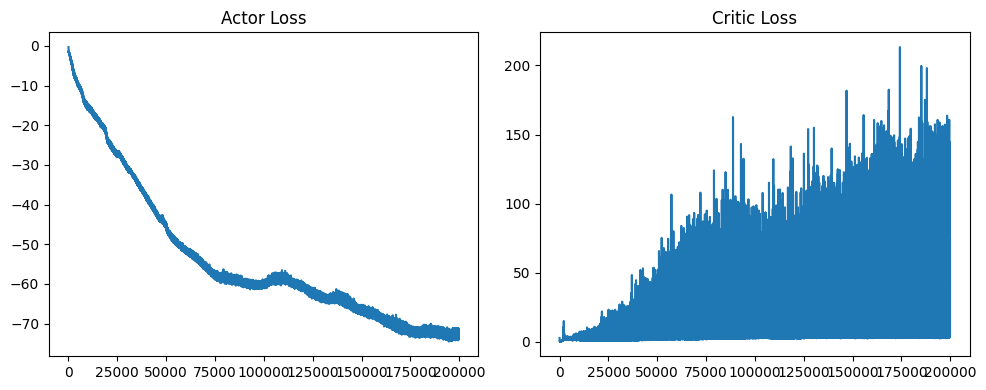

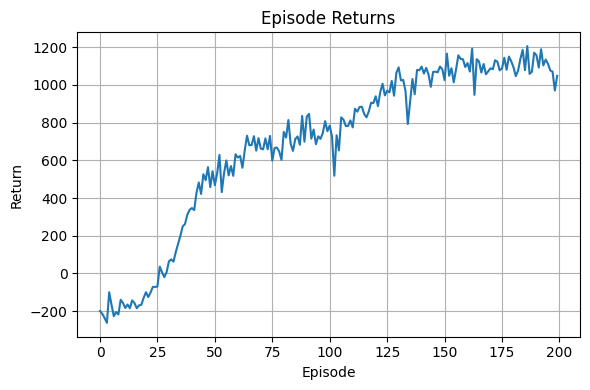

Training with sparsity 0.95


Training episodes:   0%|          | 1/200 [00:06<22:18,  6.72s/it]

Episode 0, Return: -240.55


Training episodes:   6%|▌         | 11/200 [01:21<23:45,  7.54s/it]

Episode 10, Return: -191.54


...

Training episodes:  90%|█████████ | 181/200 [22:31<02:19,  7.35s/it]

Episode 180, Return: 1108.69


Training episodes:  96%|█████████▌| 191/200 [23:46<01:07,  7.53s/it]

Episode 190, Return: 1169.11


Training episodes: 100%|██████████| 200/200 [24:53<00:00,  7.47s/it]


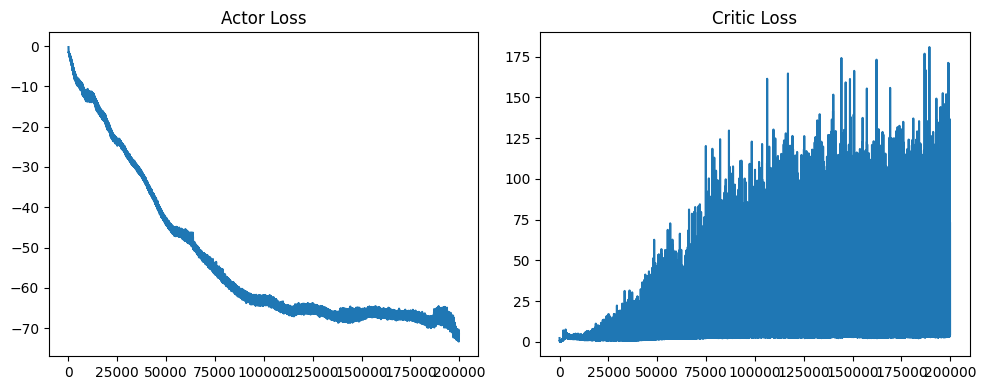

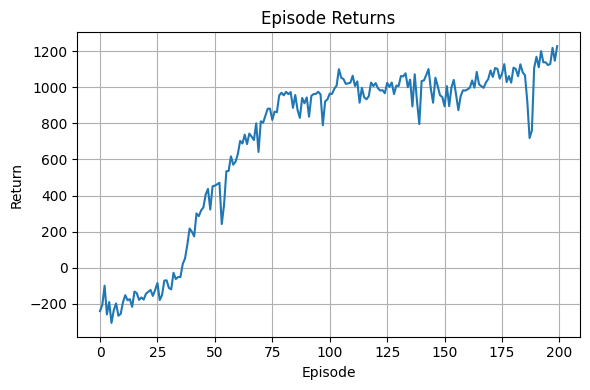

Training with sparsity 0.98


Training episodes:   0%|          | 1/200 [00:06<20:36,  6.21s/it]

Episode 0, Return: -223.87


Training episodes:   6%|▌         | 11/200 [01:17<22:24,  7.12s/it]

Episode 10, Return: -175.13


...

Training episodes:  90%|█████████ | 181/200 [21:53<02:20,  7.38s/it]

Episode 180, Return: 1037.69


Training episodes:  96%|█████████▌| 191/200 [23:06<01:06,  7.34s/it]

Episode 190, Return: 1079.59


Training episodes: 100%|██████████| 200/200 [24:12<00:00,  7.26s/it]


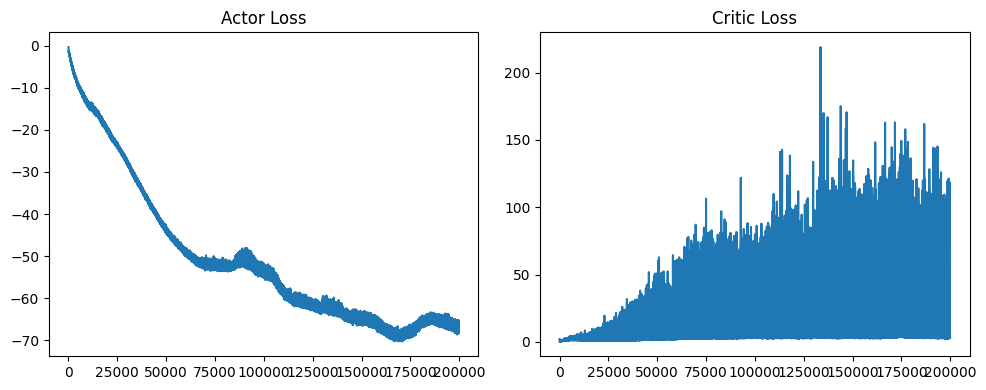

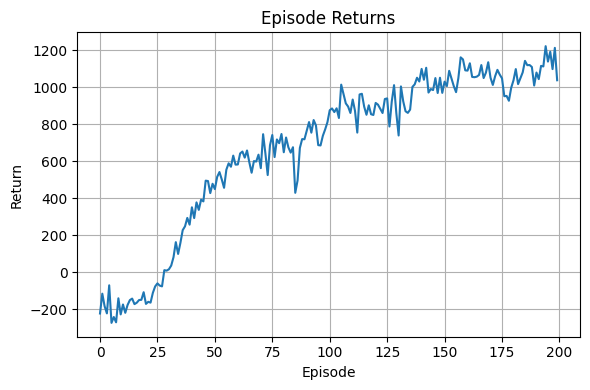

In [20]:
for sparsity in [0.90, 0.95, 0.98]:
    print(f"Training with sparsity {sparsity}")
    returns, actor_loss, critic_loss = train_dapd("HalfCheetah-v4", num_episodes=200, sparsity=sparsity)
    plot_loss(actor_loss, critic_loss)
    plot_returns(returns)

c:\Users\Proprio\AppData\Local\Programs\Python\Python311\Lib\site-packages\gymnasium\envs\registration.py:517: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Training with sparsity 0.9


Training episodes:   0%|          | 0/200 [00:00<?, ?it/s]

Episode 0, Return: 8.40


Training episodes:   6%|▌         | 12/200 [00:00<00:13, 14.35it/s]

...

Training episodes:  90%|█████████ | 181/200 [01:44<00:13,  1.36it/s]

Episode 180, Return: 227.07


Training episodes:  96%|█████████▌| 191/200 [01:51<00:05,  1.65it/s]

Episode 190, Return: 85.41


Training episodes: 100%|██████████| 200/200 [01:58<00:00,  1.69it/s]


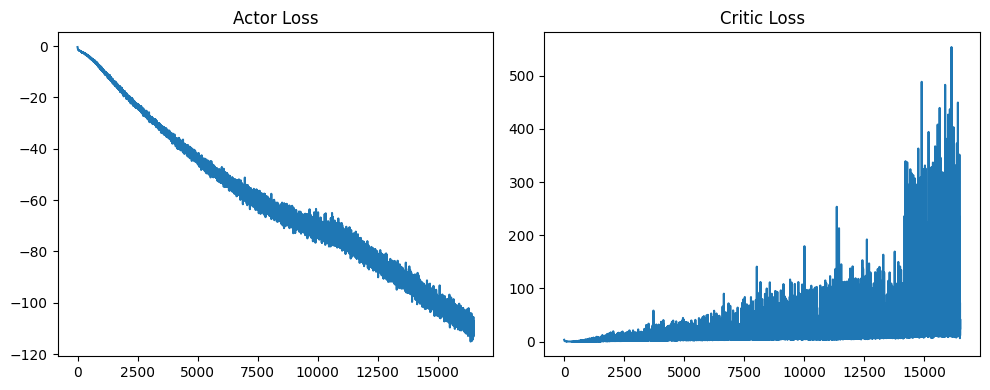

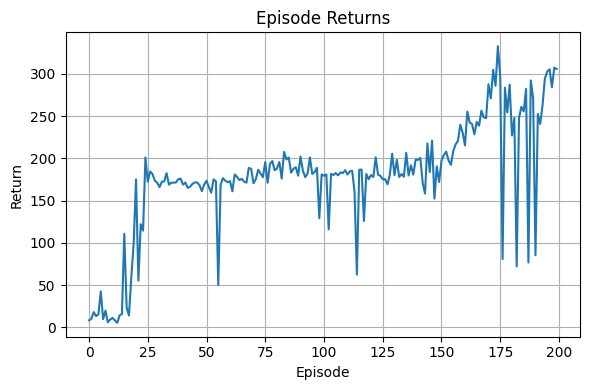

Training with sparsity 0.95


Training episodes:   2%|▎         | 5/200 [00:00<00:04, 42.39it/s]

Episode 0, Return: 9.88


Training episodes:   5%|▌         | 10/200 [00:00<00:16, 11.58it/s]

Episode 10, Return: 16.43


...

Training episodes:  90%|█████████ | 181/200 [02:17<00:15,  1.23it/s]

Episode 180, Return: 252.33


Training episodes:  96%|█████████▌| 191/200 [02:25<00:06,  1.35it/s]

Episode 190, Return: 225.23


Training episodes: 100%|██████████| 200/200 [02:34<00:00,  1.29it/s]


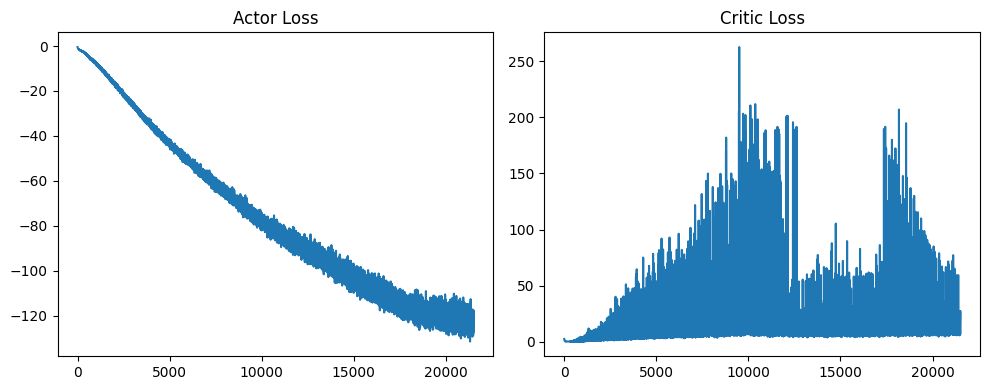

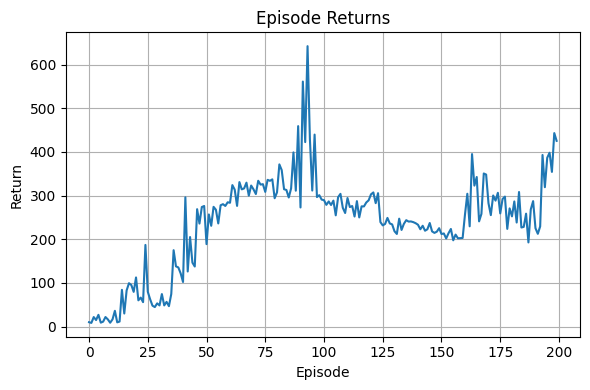

Training with sparsity 0.98


Training episodes:   4%|▎         | 7/200 [00:00<00:03, 48.96it/s]

Episode 0, Return: 34.00


Training episodes:   6%|▌         | 12/200 [00:00<00:12, 14.51it/s]

Episode 10, Return: 7.23


...

Training episodes:  90%|█████████ | 181/200 [01:31<00:12,  1.48it/s]

Episode 180, Return: 217.77


Training episodes:  96%|█████████▌| 191/200 [01:38<00:06,  1.40it/s]

Episode 190, Return: 201.14


Training episodes: 100%|██████████| 200/200 [01:45<00:00,  1.90it/s]


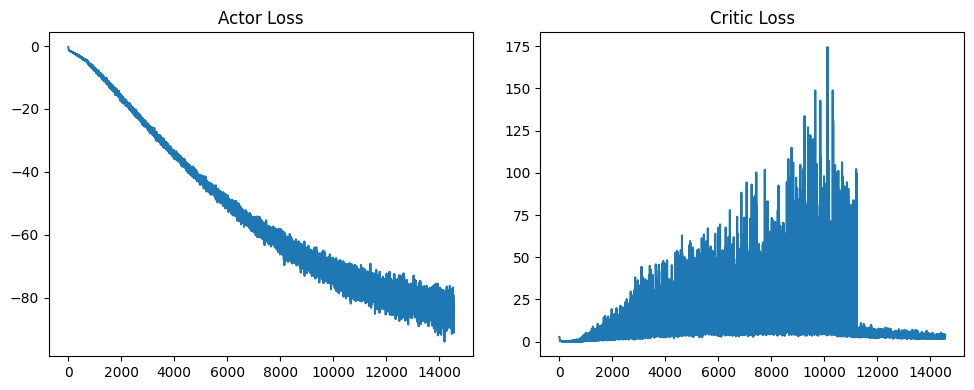

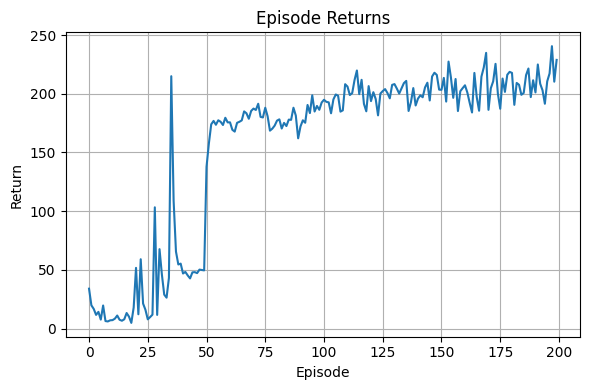

In [21]:
for sparsity in [0.90, 0.95, 0.98]:
    print(f"Training with sparsity {sparsity}")
    returns, actor_loss, critic_loss = train_dapd("Hopper-v4", num_episodes=200, sparsity=sparsity)
    plot_loss(actor_loss, critic_loss)
    plot_returns(returns)

c:\Users\Proprio\AppData\Local\Programs\Python\Python311\Lib\site-packages\gymnasium\envs\registration.py:517: DeprecationWarning: WARN: The environment Ant-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Training with sparsity 0.9


Training episodes:   0%|          | 1/200 [00:00<00:21,  9.09it/s]

Episode 0, Return: -43.10


Training episodes:   6%|▌         | 11/200 [00:11<03:13,  1.02s/it]

...

Training episodes:  90%|█████████ | 181/200 [17:59<03:03,  9.68s/it]

Episode 180, Return: 1043.48


Training episodes:  96%|█████████▌| 191/200 [18:39<00:27,  3.09s/it]

Episode 190, Return: 412.91


Training episodes: 100%|██████████| 200/200 [19:42<00:00,  5.91s/it]


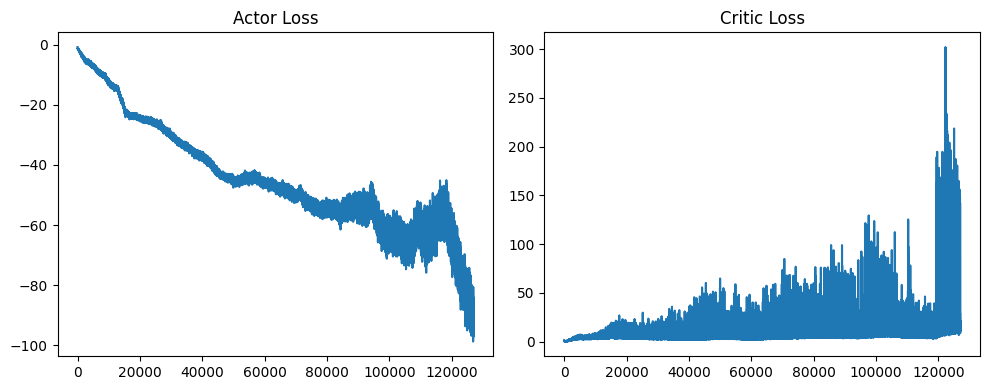

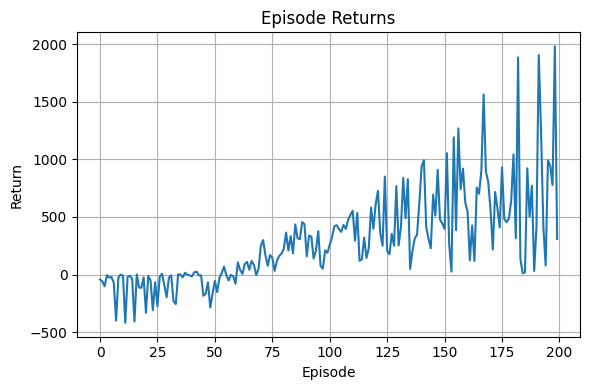

Training with sparsity 0.95


Training episodes:   2%|▏         | 3/200 [00:00<00:08, 24.00it/s]

Episode 0, Return: 27.41


Training episodes:   6%|▌         | 11/200 [00:03<01:03,  2.96it/s]

Episode 10, Return: -23.05


...

Training episodes:  90%|█████████ | 181/200 [14:14<01:58,  6.24s/it]

Episode 180, Return: 3414.98


Training episodes:  96%|█████████▌| 191/200 [15:30<01:13,  8.17s/it]

Episode 190, Return: -2999.11


Training episodes: 100%|██████████| 200/200 [16:46<00:00,  5.03s/it]


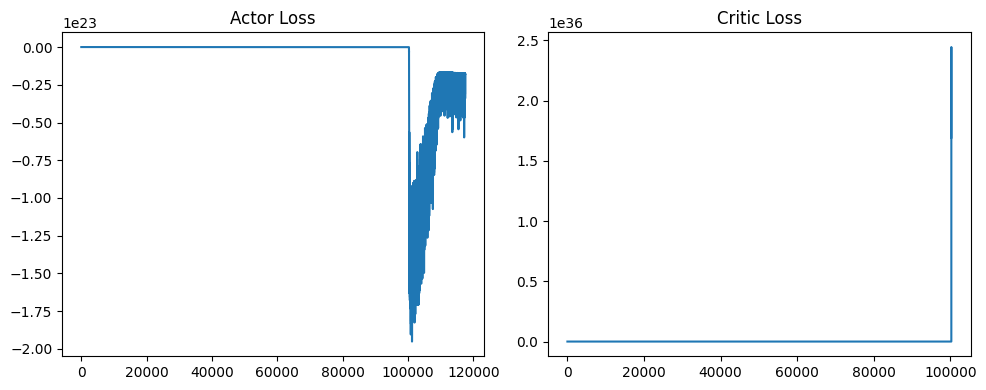

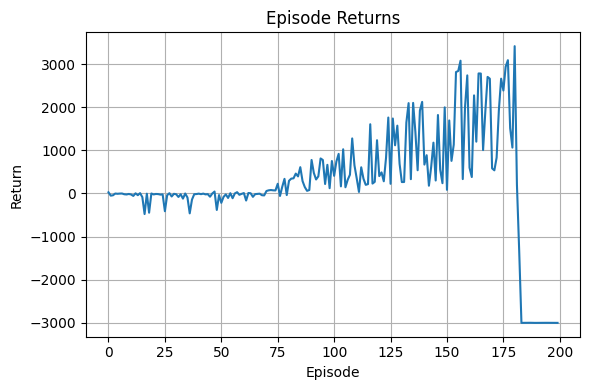

Training with sparsity 0.98


Training episodes:   1%|          | 2/200 [00:08<11:24,  3.46s/it]

Episode 0, Return: -361.87


Training episodes:   6%|▌         | 11/200 [00:25<04:17,  1.36s/it]

Episode 10, Return: -1.03


...

Training episodes:  90%|█████████ | 181/200 [15:52<02:11,  6.91s/it]

Episode 180, Return: 1089.75


Training episodes:  96%|█████████▌| 191/200 [17:16<01:18,  8.71s/it]

Episode 190, Return: 775.30


Training episodes: 100%|██████████| 200/200 [18:39<00:00,  5.60s/it]


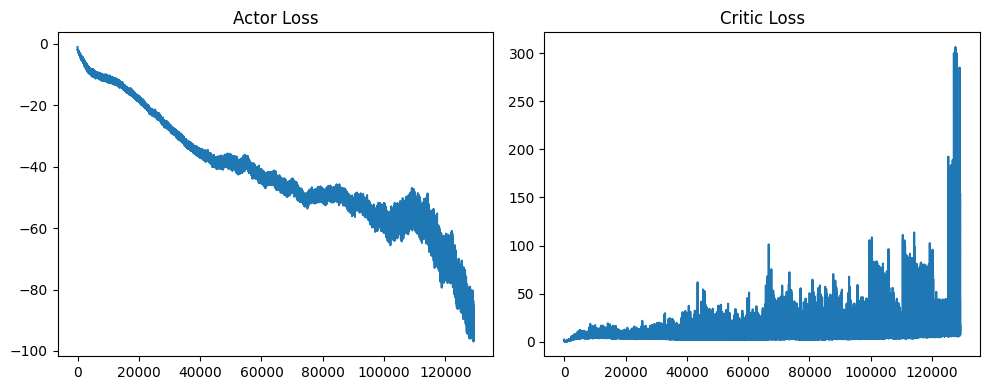

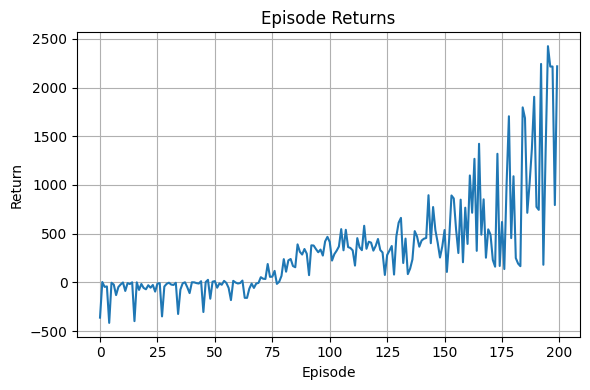

In [22]:
for sparsity in [0.90, 0.95, 0.98]:
    print(f"Training with sparsity {sparsity}")
    returns, actor_loss, critic_loss = train_dapd("Ant-v4", num_episodes=200, sparsity=sparsity)
    plot_loss(actor_loss, critic_loss)
    plot_returns(returns)